Reality check so far:

1. Load clean reviews and orders created in notebook 00
2. Use data_utils.py to clean extra raw product/category files
3. Merge reviews with logistics and product categories
4. Detect emotions using a lightweight keyword-based approach
5. Test whether anger is linked to late delivery
6. Test which categories are linked to joy or anger
7. Save the final dataset for the team

In [32]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../")

from src.data_utils import snake_columns

In [33]:
PROCESSED_PATH = Path("../data/processed")
RAW_PATH = Path("../data/raw")
OUTPUT_PATH = Path("../outputs/figures")

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

In [34]:
reviews = pd.read_csv(PROCESSED_PATH / "reviews_clean.csv")
orders = pd.read_csv(PROCESSED_PATH / "orders_clean.csv")

order_items = pd.read_csv(RAW_PATH / "olist_order_items_dataset.csv")
products = pd.read_csv(RAW_PATH / "olist_products_dataset.csv")
category_translation = pd.read_csv(RAW_PATH / "product_category_name_translation.csv")

In [35]:
order_items = snake_columns(order_items)
products = snake_columns(products)
category_translation = snake_columns(category_translation)

In [36]:
print(reviews.columns.tolist())
print(orders.columns.tolist())
print(order_items.columns.tolist())
print(products.columns.tolist())
print(category_translation.columns.tolist())

['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'review_text', 'has_review_text']
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_time_days', 'estimated_delivery_days', 'delivery_delay_days', 'is_late']
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
['product_category_name', 'product_category_name_english']


In [37]:
# Merge reviews with delivery and product category data
df = reviews.merge(
    orders[
        [
            "order_id",
            "order_status",
            "delivery_time_days",
            "estimated_delivery_days",
            "delivery_delay_days",
            "is_late"
        ]
    ],
    on="order_id",
    how="left"
)

df = df.merge(
    order_items[["order_id", "product_id"]],
    on="order_id",
    how="left"
)

df = df.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

df = df.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

df.shape

(113131, 17)

In [38]:
# Keep only reviews with text
df = df[df["has_review_text"] == True].copy()
df["review_text"] = df["review_text"].fillna("").astype(str)

df.shape

(50055, 17)

In [39]:
# Create emotion keywords list
anger_words = [
    # delivery / logistics
    "atraso", "atrasado", "demora", "demorou", "demorado",
    "não chegou", "nao chegou", "nunca chegou",
    
    # product issues
    "defeito", "quebrado", "danificado", "produto errado",
    
    # strong negative sentiment
    "péssimo", "pessimo", "horrível", "horrivel",
    "absurdo", "frustrado", "decepcionado",
    
    # high-signal English only
    "late", "delay", "never arrived", "broken", "wrong product"
]

joy_words = [
    "ótimo", "otimo", "excelente", "perfeito",
    "amei", "adorei",
    
    # delivery experience
    "rápido", "rapido", "chegou antes", "entrega rápida",
    
    # satisfaction
    "recomendo", "satisfeito", "satisfeita",
    
    # quality
    "qualidade", "lindo", "linda",
    
    # high-signal English
    "excellent", "perfect", "love", "fast delivery"
]

sadness_words = [
    "triste", "decepcionante", "infelizmente",
    "esperava mais",
    "disappointed", "unhappy"
]

Choice of keywords optimized for:
- Less noise → fewer false positives
- More cause-driven (delivery, product issues)

Instead of using a generic sentiment model, we designed a targeted keyword-based emotion detection focused on customer experience drivers such as delivery delays and product issues.

In [40]:
# Emotion detection function
def detect_emotion(text):
    text = text.lower()

    anger_count = sum(word in text for word in anger_words)
    joy_count = sum(word in text for word in joy_words)
    sadness_count = sum(word in text for word in sadness_words)

    scores = {
        "anger": anger_count,
        "joy": joy_count,
        "sadness": sadness_count
    }

    max_emotion = max(scores, key=scores.get)

    if scores[max_emotion] == 0:
        return "neutral"

    return max_emotion

In [41]:
# Apply emotion detector
df["emotion_label"] = df["review_text"].apply(detect_emotion)

df["emotion_label"].value_counts()

emotion_label
neutral    27176
joy        18986
anger       3703
sadness      190
Name: count, dtype: int64

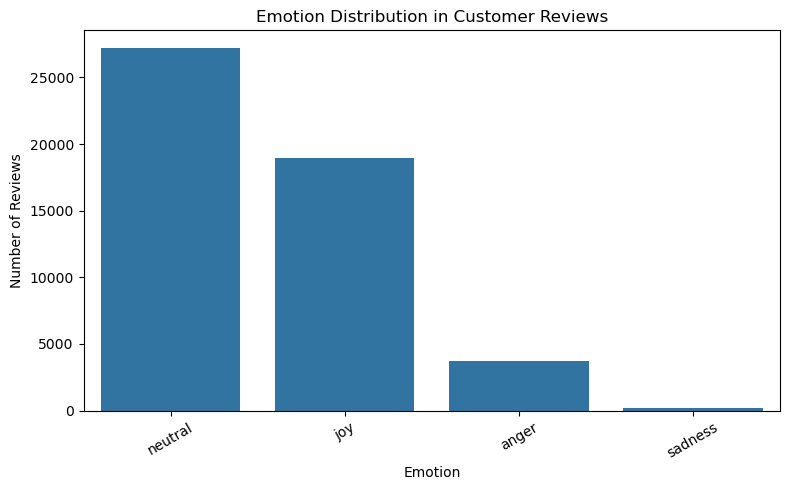

In [42]:
# Emotion distribution plot
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="emotion_label",
    order=df["emotion_label"].value_counts().index
)

plt.title("Emotion Distribution in Customer Reviews")
plt.xlabel("Emotion")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig(OUTPUT_PATH / "emotion_distribution.png", dpi=300)
plt.show()

In [43]:
# Delivery status column
df["delivery_status"] = np.where(df["is_late"], "Late", "On time / Early")

In [44]:
# Anger rate by delivery status
anger_by_delivery = (
    df.groupby("delivery_status")["emotion_label"]
    .apply(lambda x: (x == "anger").mean() * 100)
    .reset_index(name="anger_rate_percent")
)

anger_by_delivery

,delivery_status,anger_rate_percent
0,Late,23.562412
1,On time / Early,5.887236


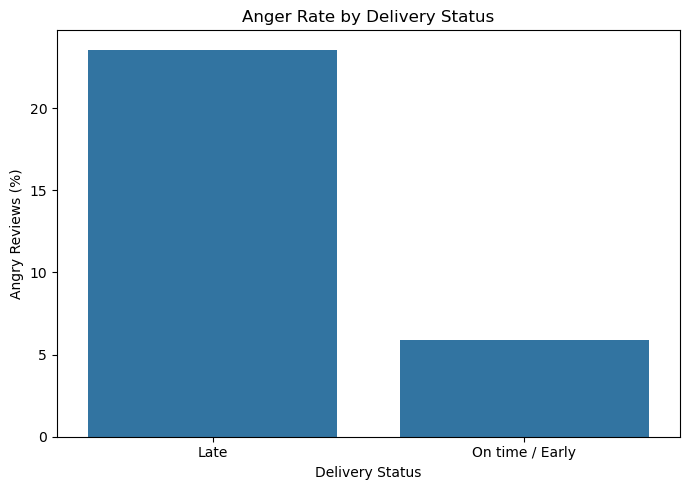

In [45]:
# Chart: Anger and Logistics
plt.figure(figsize=(7, 5))

sns.barplot(
    data=anger_by_delivery,
    x="delivery_status",
    y="anger_rate_percent"
)

plt.title("Anger Rate by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Angry Reviews (%)")

plt.tight_layout()
plt.savefig(OUTPUT_PATH / "anger_rate_by_delivery_status.png", dpi=300)
plt.show()

In [46]:
# Joy category
joy_by_category = (
    df[df["emotion_label"] == "joy"]
    .groupby("product_category_name_english")
    .size()
    .reset_index(name="joy_reviews")
    .sort_values("joy_reviews", ascending=False)
    .head(10)
)

joy_by_category

,product_category_name_english,joy_reviews
7,bed_bath_table,2228
43,health_beauty,1573
39,furniture_decor,1388
65,sports_leisure,1226
49,housewares,1219
70,watches_gifts,1148
15,computers_accessories,1017
42,garden_tools,833
68,telephony,769
5,auto,724


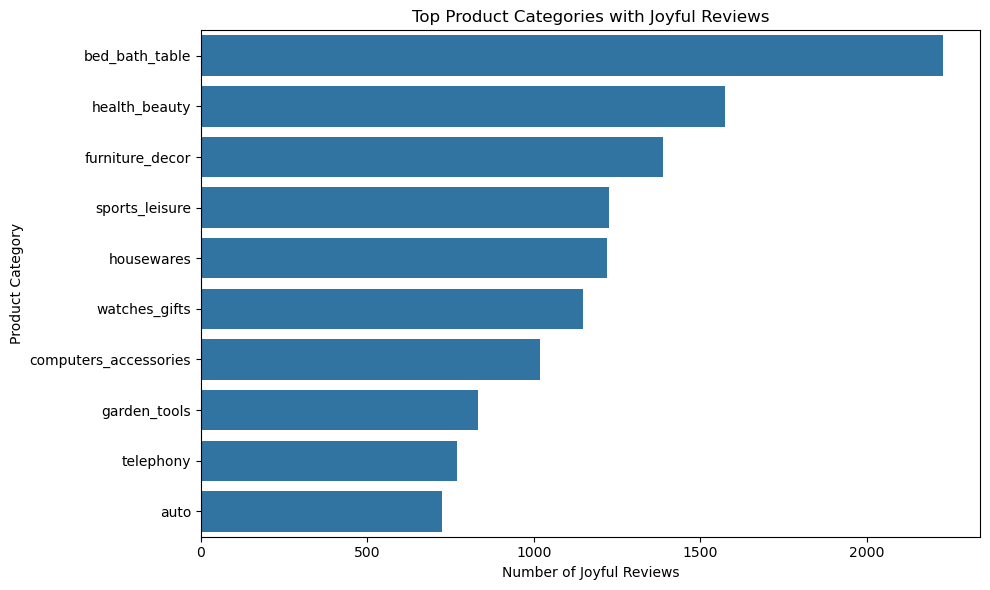

In [47]:
# Chart: Top Joyful Categories
plt.figure(figsize=(10, 6))

sns.barplot(
    data=joy_by_category,
    y="product_category_name_english",
    x="joy_reviews"
)

plt.title("Top Product Categories with Joyful Reviews")
plt.xlabel("Number of Joyful Reviews")
plt.ylabel("Product Category")

plt.tight_layout()
plt.savefig(OUTPUT_PATH / "top_joyful_categories.png", dpi=300)
plt.show()

In [48]:
# Anger by category
anger_by_category = (
    df[df["emotion_label"] == "anger"]
    .groupby("product_category_name_english")
    .size()
    .reset_index(name="angry_reviews")
    .sort_values("angry_reviews", ascending=False)
    .head(10)
)

anger_by_category

,product_category_name_english,angry_reviews
14,computers_accessories,319
7,bed_bath_table,304
37,health_beauty,287
55,sports_leisure,261
33,furniture_decor,251
60,watches_gifts,228
43,housewares,211
58,telephony,189
19,cool_stuff,129
5,auto,125


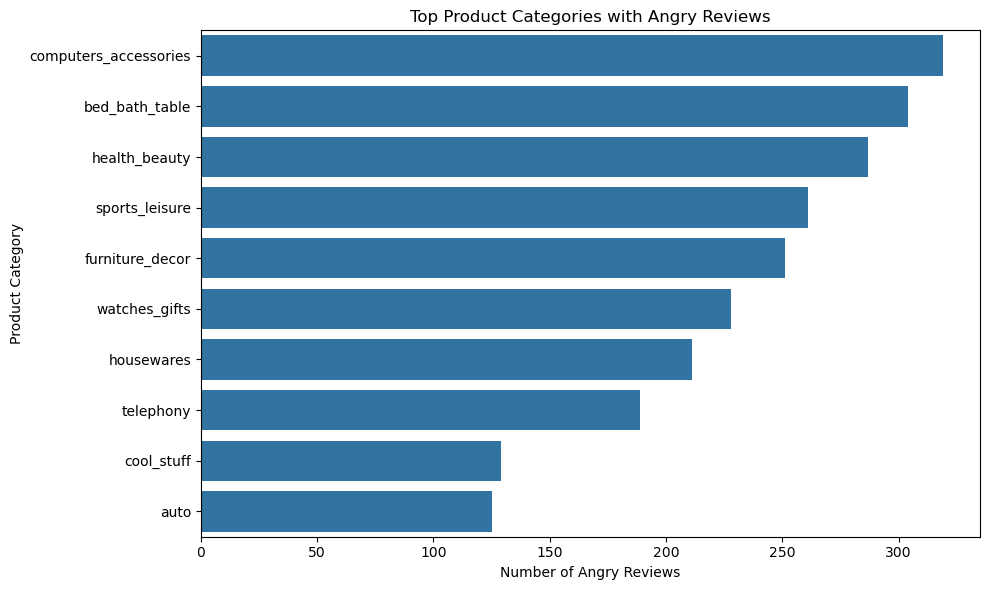

In [49]:
# Chart: Top Angry Categories
plt.figure(figsize=(10, 6))

sns.barplot(
    data=anger_by_category,
    y="product_category_name_english",
    x="angry_reviews"
)

plt.title("Top Product Categories with Angry Reviews")
plt.xlabel("Number of Angry Reviews")
plt.ylabel("Product Category")

plt.tight_layout()
plt.savefig(OUTPUT_PATH / "top_angry_categories.png", dpi=300)
plt.show()

In [50]:
# Avg review score by emotion
score_by_emotion = (
    df.groupby("emotion_label")["review_score"]
    .mean()
    .reset_index()
    .sort_values("review_score")
)

score_by_emotion

,emotion_label,review_score
0,anger,1.957332
3,sadness,2.152632
2,neutral,3.146931
1,joy,4.541452


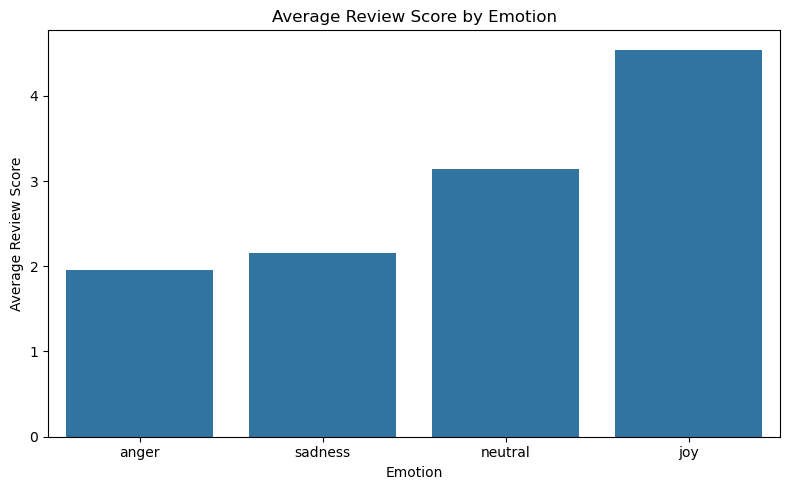

In [51]:
# Chart: Score by Emotion
plt.figure(figsize=(8, 5))

sns.barplot(
    data=score_by_emotion,
    x="emotion_label",
    y="review_score"
)

plt.title("Average Review Score by Emotion")
plt.xlabel("Emotion")
plt.ylabel("Average Review Score")

plt.tight_layout()
plt.savefig(OUTPUT_PATH / "average_score_by_emotion.png", dpi=300)
plt.show()

In [52]:
# Example angry reviews
angry_examples = df[df["emotion_label"] == "anger"][
    [
        "review_score",
        "review_text",
        "delivery_delay_days",
        "is_late",
        "product_category_name_english"
    ]
].head(10)

angry_examples

,review_score,review_text,delivery_delay_days,is_late,product_category_name_english
28,1,Não chegou meu produto Péssimo,NaN,False,luggage_accessories
87,1,O produto não chegou no prazo estipulado e cau...,NaN,False,auto
162,2,Demorou de mais pra entrega,14.0,True,housewares
168,3,Entrega atrasou A entrega foi dividida em duas...,-48.0,False,baby
211,4,4 Se fosse vidro tinha quebrado; veio na cai...,-3.0,False,furniture_decor
212,4,4 Se fosse vidro tinha quebrado; veio na cai...,-3.0,False,furniture_decor
214,1,Comprei o produto dia 25 de fevereiro e hoje d...,8.0,True,audio
239,1,falta de produto e quebra Faltou 1 produto e o...,-20.0,False,housewares
240,1,falta de produto e quebra Faltou 1 produto e o...,-20.0,False,housewares
241,1,falta de produto e quebra Faltou 1 produto e o...,-20.0,False,housewares


In [53]:
# Example joyful reviews
joy_examples = df[df["emotion_label"] == "joy"][
    [
        "review_score",
        "review_text",
        "delivery_delay_days",
        "is_late",
        "product_category_name_english"
    ]
].head(10)

joy_examples

,review_score,review_text,delivery_delay_days,is_late,product_category_name_english
5,5,Parabéns lojas lannister adorei comprar pela I...,-9.0,False,sports_leisure
13,4,recomendo aparelho eficiente. no site a marca ...,-16.0,False,small_appliances
24,5,"Super recomendo Vendedor confiável, produto ok...",-16.0,False,computers_accessories
33,5,Ótimo Loja nota 10,-14.0,False,health_beauty
49,5,"Bom Recomendo ,",-17.0,False,pet_shop
62,5,"otimo vendedor chegou ate antes do prazo , ado...",-15.0,False,health_beauty
69,5,Ótimo,0.0,False,cool_stuff
75,5,MT lindo MT lindo,-13.0,False,watches_gifts
77,5,Ocorreu tudo como contratado sendo a entrega r...,-19.0,False,garden_tools
78,5,Ocorreu tudo como contratado sendo a entrega r...,-19.0,False,furniture_decor


In [54]:
df.to_csv(PROCESSED_PATH / "reviews_emotions_categories.csv", index=False)

print("Saved reviews_emotions_categories.csv")

Saved reviews_emotions_categories.csv


In [55]:
total_reviews = len(df)
anger_rate = (df["emotion_label"] == "anger").mean() * 100
joy_rate = (df["emotion_label"] == "joy").mean() * 100

late_anger_rate = anger_by_delivery.loc[
    anger_by_delivery["delivery_status"] == "Late",
    "anger_rate_percent"
].values[0]

ontime_anger_rate = anger_by_delivery.loc[
    anger_by_delivery["delivery_status"] == "On time / Early",
    "anger_rate_percent"
].values[0]

print(f"Total analyzed reviews: {total_reviews}")
print(f"Anger rate: {anger_rate:.2f}%")
print(f"Joy rate: {joy_rate:.2f}%")
print(f"Anger rate for late deliveries: {late_anger_rate:.2f}%")
print(f"Anger rate for on-time/early deliveries: {ontime_anger_rate:.2f}%")

Total analyzed reviews: 50055
Anger rate: 7.40%
Joy rate: 37.93%
Anger rate for late deliveries: 23.56%
Anger rate for on-time/early deliveries: 5.89%
